In [ ]:
import pandas as pd

# Load Plant 2's generation data (same structure as Plant 1, different plant)
gen_data_p2 = pd.read_csv('../data/Plant_2_Generation_Data.csv')
gen_data_p2.head()


In [1]:
import pandas as pd

# Load Plant 2's generation data (same structure as Plant 1, different plant)
gen_data_p2 = pd.read_csv('../data/Plant_2_Generation_Data.csv')
gen_data_p2.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


In [2]:
# Plant 2 uses YYYY-MM-DD HH:MM:SS format (different from Plant 1!)
gen_data_p2['DATE_TIME'] = pd.to_datetime(gen_data_p2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
gen_data_p2.info()

<class 'pandas.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    67698 non-null  datetime64[us]
 1   PLANT_ID     67698 non-null  int64         
 2   SOURCE_KEY   67698 non-null  str           
 3   DC_POWER     67698 non-null  float64       
 4   AC_POWER     67698 non-null  float64       
 5   DAILY_YIELD  67698 non-null  float64       
 6   TOTAL_YIELD  67698 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 4.6 MB


In [3]:
# Add a DATE column (date only, no time) for grouping by day
gen_data_p2['DATE'] = gen_data_p2['DATE_TIME'].dt.date

# Sum AC_POWER across all inverters, grouped by day - same approach as Plant 1
daily_total_p2 = gen_data_p2.groupby('DATE')['AC_POWER'].sum()

# Plot Plant 1 and Plant 2 daily totals together for direct comparison
plt.figure(figsize=(12, 5))
plt.plot(daily_total.index, daily_total.values, marker='o', label='Plant 1', color='tab:blue')
plt.plot(daily_total_p2.index, daily_total_p2.values, marker='o', label='Plant 2', color='tab:green')

plt.title('Daily Total AC Power Generation: Plant 1 vs. Plant 2')
plt.xlabel('Date')
plt.ylabel('Total AC Power (kW)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

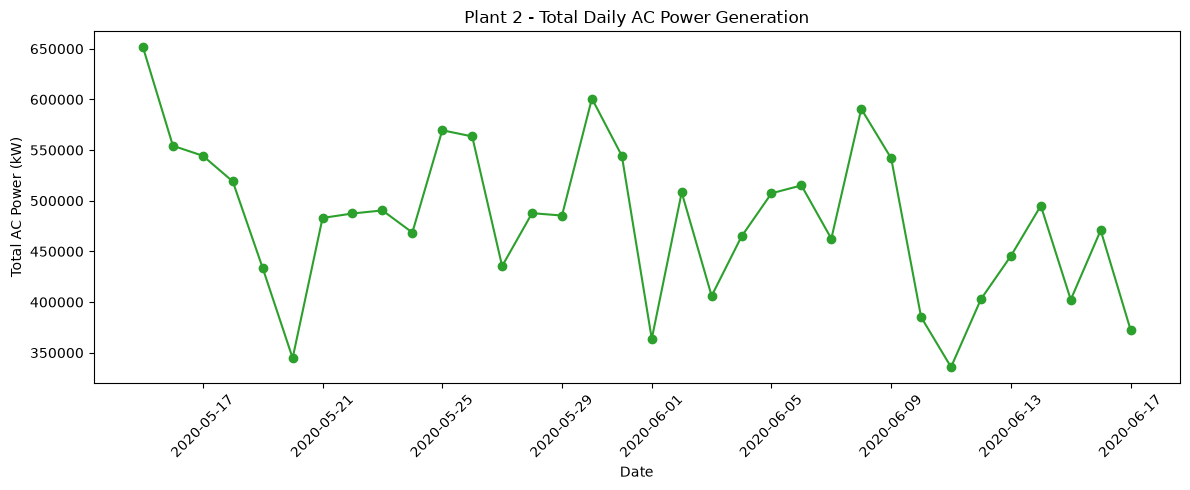

In [4]:
import matplotlib.pyplot as plt

# Plot Plant 2's daily total AC power generation
plt.figure(figsize=(12, 5))
plt.plot(daily_total_p2.index, daily_total_p2.values, marker='o', color='tab:green')
plt.title('Plant 2 - Total Daily AC Power Generation')
plt.xlabel('Date')
plt.ylabel('Total AC Power (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Finding: Plant 2 shows lower and more volatile output than Plant 1

Plant 2's daily total AC power peaks around 600,000-650,000 kW, 
noticeably lower than Plant 1's peak of ~750,000-800,000 kW. Plant 2's 
day-to-day pattern is also choppier, with a sharp dip around 2020-05-20/21 
and another deep dip near 2020-06-10 that don't clearly mirror Plant 1's dip days.

**Takeaway:** This could reflect a smaller installed capacity at Plant 2, 
different weather conditions at its location, or different equipment 
performance. Needs Plant 2's own weather sensor data to confirm whether 
this is weather-driven (like Plant 1) or something else.